In [8]:
import numpy as np
import pandas as pd
# pd.set_option('display.max_columns', 30)
# pd.set_option('display.max_rows', None)
import matplotlib.pyplot as plt
import glob, json

%load_ext autoreload
%autoreload 2

from cmlreaders import get_data_index, CMLReader

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
from datetime import datetime

def ms_to_datetime(mstime):
    # Convert milliseconds to seconds and then to a datetime object
    return datetime.fromtimestamp(mstime / 1000.0)

def _get_field(obj, key):
    """Return obj[key]; tolerate obj being a JSON-encoded string or non-dict.

    Older session.jsonl files (e.g. R1556J_1, FBG490) store data['message']
    as a stringified JSON object (or even a bare string like 'FNSBOPENUSB')
    rather than a nested dict, which raised
    "descriptor get for dict objects doesn't apply to a str object".
    """
    import json
    if isinstance(obj, str):
        try:
            obj = json.loads(obj)
        except (json.JSONDecodeError, ValueError):
            return None
    if isinstance(obj, dict):
        return obj.get(key)
    return None


def get_heart(subject, exp, sess, load_host_pc=False, drop_network_test=False, verbose=False):
    # Finds and reads the session log file from the task laptop
    # sess: int, original session number (used in /data10 session_*/ directory)
    log_dir = f'/data10/RAM/subjects/{subject}/behavioral/{exp}/session_{sess}'
    if load_host_pc:
        log_dir += '/elemem/*/event.log'
    else:
        if exp in ['catFR1']:
            log_dir += '/session.json'
        else:
            log_dir += '/session.jsonl'
    log_dir_list = glob.glob(log_dir)
    if verbose:
        print(log_dir_list)
    if len(log_dir_list) != 1: raise ValueError(f'Log not found: {str(log_dir_list)}')
    heart_beat = []
    # read session log to dataframe
    for log_dir in log_dir_list:
        log = []
        with open(log_dir, 'r') as fr:
            lines = fr.readlines()
            for line in lines:
                try: log.append(json.loads(line))
                except Exception as e: continue
        temp = pd.DataFrame(log)
        temp['session'] = int(sess)
        heart_beat.append(temp)
    heart_beat = pd.concat(heart_beat)
    # reads the data out of the dict format
    if load_host_pc:
        heart_beat = heart_beat[heart_beat.type.isin(['HEARTBEAT', 'HEARTBEAT_OK'])]
        heart_beat['count'] = heart_beat.data.apply(lambda x: _get_field(x, 'count'))
    else:
        heart_beat['message'] = heart_beat.data.apply(lambda x: _get_field(x, 'message'))
        heart_beat.dropna(subset=['message'], inplace=True)
        heart_beat['type'] = heart_beat.message.apply(lambda x: _get_field(x, 'type'))
        heart_beat['data'] = heart_beat.message.apply(lambda x: _get_field(x, 'data'))
        heart_beat = heart_beat[heart_beat.type.isin(['HEARTBEAT', 'HEARTBEAT_OK'])]
        heart_beat['count'] = heart_beat.data.apply(lambda x: _get_field(x, 'count'))
        if len(heart_beat) == 0: raise ValueError('No HEARTBEAT / HEARTBEAT_OK events logged!')

    # skip heartbeats after initial heartbeat test, which is required to pass before starting a session
    if drop_network_test:
        heart_beat = heart_beat[heart_beat['count'] > 20]

    assert len(heart_beat.session.unique()) == 1, f'session numbers not unique (or not present): {heart_beat.session.unique()}'
    bpm_sent = pd.DataFrame()
    bpm_done = pd.DataFrame()
    bpm_sent = heart_beat[heart_beat.type == 'HEARTBEAT']
    bpm_done = heart_beat[heart_beat.type == 'HEARTBEAT_OK']
    bpm_done.set_index('count', inplace = True)
    bpm_sent.set_index('count', inplace = True)

    # Gets the latency between when the signal is sent and when Elemem sends the signal out
    bpm_err = bpm_done.time.astype(float) - bpm_sent.time.astype(float)
    # bpm_err = bpm_err[bpm_err.index > 20]  # not sure why Leo included this since heartbeats from network test are dropped earlier
    _max = round(bpm_err.max(), 2)
    _min = round(bpm_err.min(), 2)
    ten = round(bpm_err.quantile(.10), 2)
    ninety = round(bpm_err.quantile(.90), 2)
    out_count = bpm_err[bpm_err > 100].count()
    
    hardware_system = 'host_pc' if load_host_pc else 'task_laptop'
    if verbose:
        # print(f'{subject} {exp} session', sess)
        print('HEARTBEAT statistics for', hardware_system)
        print(f'Minimum latency: {_min} ms, Maximum latency: {_max} ms')
        print(f'Tenth percentile latency: {ten} ms. Ninetieth percentile latency: {ninety} ms')
        print(f'Latencies greater than 100 ms: {out_count / len(bpm_err) * 100:0.4}%\n')

    heart_beat = heart_beat.query('type == "HEARTBEAT"')
    if 'message' in heart_beat.columns: 
        heart_beat.drop('message', axis=1, inplace=True)
    heart_beat.set_index('count', inplace=True, drop=False)
    heart_beat.loc[:, ['latency']] = bpm_err
    heart_beat.loc[:, ['time_HEARTBEAT_OK']] = bpm_done.time
    heart_beat.loc[:, ['subject']] = subject
    heart_beat.loc[:, ['experiment']] = exp
    heart_beat.loc[:, ['session']] = sess
    heart_beat.loc[:, ['hardware_system']] = hardware_system
    heart_beat = heart_beat.reindex(columns=['subject', 'experiment', 'session', 'original_session', 'hardware_system',
                                             'count', 'time', 'time_HEARTBEAT_OK', 'latency', 'id'])

    # if verbose:
    #     heart_beat_cp = heart_beat.copy().dropna()
    #     heart_beat_cp['time'] = heart_beat_cp.time.astype(int).apply(ms_to_datetime)
    #     heart_beat_cp['time_HEARTBEAT_OK'] = heart_beat_cp.time_HEARTBEAT_OK.astype(int).apply(ms_to_datetime)
    #     display(heart_beat_cp[['latency', 'time', 'time_HEARTBEAT_OK']].head(25))

    return heart_beat


In [10]:
# check heartbeats for all behavioral tasks
exps = ['RepFR1',#'RepFR2', #'RepFR1',  # just run RepFR1 for now
        # 'EFRCourierOpenLoop', 'EFRCourierReadOnly',  # several early sessions with errors
        # 'catFR1', 'ICatFR1', 'IFR1'  # HEARTBEATs were not recorded on the task side for these experiments...
]

data = get_data_index(kind = 'r1').query('system_version == 4 and experiment in @exps')

drop_network_test = True
smokescreen = True
if smokescreen:
    # i = -2
    # data = data.query('experiment == "RepFR2"').iloc[i:i+1]
    
    # for now only load first 40 sessions since loading all somehow causes out-of-memory errors, even with 60 GB
    data = data.iloc[:40]
    
    # data = data.query('experiment == "catFR1"')#.iloc[i:i+1]
    # data = data.query('experiment in ["EFRCourierOpenLoop", "EFRCourierReadOnly"]')#.iloc[i:i+1]
    # data = data.query('experiment in ["catFR1", "ICatFR1", "IFR1"]')#.iloc[i:i+1]

# heartbeat errors
heartbeats = list()
for idx, row in data.iterrows():
    try:
        print('------------------------------------------------------------------------------------')
        print(f'{row.subject}, {row.experiment}, session {row.session}')
        r = CMLReader(subject=row.subject, experiment=row.experiment, session=row.session, 
                      localization=row.localization, montage=row.montage)
        evs = r.load('events')
        sess = row.original_session if not row.isna().original_session else row.session
        # load HEARTBEATs in session.jsonl (recorded by task laptop)
        tmp = get_heart(row.subject_alias, row.experiment, sess,
                        drop_network_test=drop_network_test, 
                        load_host_pc=False, verbose=True)
        tmp['original_session'] = tmp.session
        tmp.loc[:, ['session']] = row.session
        heartbeats.append(tmp)
        # load HEARTBEATs in event.log (recorded by host PC)
        tmp = get_heart(row.subject_alias, row.experiment, sess,
                        drop_network_test=drop_network_test, 
                        load_host_pc=True, verbose=True)
        tmp['original_session'] = tmp.session
        tmp.loc[:, ['session']] = row.session
        heartbeats.append(tmp)
        
    except Exception as e:
        print(f'Error on {row.subject_alias}, {row.experiment}, session {sess}:')
        print(e)
        # print()
        # raise(e)

heartbeats = pd.concat(heartbeats, ignore_index=True)
heartbeats.head(3)

------------------------------------------------------------------------------------
R1204T, RepFR1, session 0
['/data10/RAM/subjects/R1204T_1/behavioral/RepFR1/session_0/session.jsonl']
HEARTBEAT statistics for task_laptop
Minimum latency: 0.5 ms, Maximum latency: 336.92 ms
Tenth percentile latency: 0.75 ms. Ninetieth percentile latency: 1.2 ms
Latencies greater than 100 ms: 0.02379%

['/data10/RAM/subjects/R1204T_1/behavioral/RepFR1/session_0/elemem/R1204T_1_2021-09-30_12-31-27/event.log']
HEARTBEAT statistics for host_pc
Minimum latency: 0.0 ms, Maximum latency: 1.03 ms
Tenth percentile latency: 0.0 ms. Ninetieth percentile latency: 0.0 ms
Latencies greater than 100 ms: 0.0%



/tmp/ipykernel_141401/2604915923.py:98: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  heart_beat.drop('message', axis=1, inplace=True)


------------------------------------------------------------------------------------
R1204T, RepFR1, session 1
['/data10/RAM/subjects/R1204T_1/behavioral/RepFR1/session_1/session.jsonl']
HEARTBEAT statistics for task_laptop
Minimum latency: 0.56 ms, Maximum latency: 56.04 ms
Tenth percentile latency: 0.78 ms. Ninetieth percentile latency: 1.22 ms
Latencies greater than 100 ms: 0.0%

['/data10/RAM/subjects/R1204T_1/behavioral/RepFR1/session_1/elemem/R1204T_1_2021-10-04_13-53-20/event.log']
HEARTBEAT statistics for host_pc
Minimum latency: 0.0 ms, Maximum latency: 1.02 ms
Tenth percentile latency: 0.0 ms. Ninetieth percentile latency: 0.0 ms
Latencies greater than 100 ms: 0.0%

------------------------------------------------------------------------------------
R1204T, RepFR1, session 2


/tmp/ipykernel_141401/2604915923.py:98: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  heart_beat.drop('message', axis=1, inplace=True)


['/data10/RAM/subjects/R1204T_1/behavioral/RepFR1/session_2/session.jsonl']
HEARTBEAT statistics for task_laptop
Minimum latency: 0.61 ms, Maximum latency: 55.54 ms
Tenth percentile latency: 0.83 ms. Ninetieth percentile latency: 1.47 ms
Latencies greater than 100 ms: 0.0%

['/data10/RAM/subjects/R1204T_1/behavioral/RepFR1/session_2/elemem/R1204T_1_2021-10-05_11-01-06/event.log']
HEARTBEAT statistics for host_pc
Minimum latency: 0.0 ms, Maximum latency: 1.01 ms
Tenth percentile latency: 0.0 ms. Ninetieth percentile latency: 0.0 ms
Latencies greater than 100 ms: 0.0%



...

HEARTBEAT statistics for task_laptop
Minimum latency: 0.66 ms, Maximum latency: 229.71 ms
Tenth percentile latency: 0.93 ms. Ninetieth percentile latency: 1.55 ms
Latencies greater than 100 ms: 1.531%

['/data10/RAM/subjects/R1611T/behavioral/RepFR1/session_1/elemem/R1611T_2022-04-22_09-50-30/event.log']


/tmp/ipykernel_141401/2604915923.py:98: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  heart_beat.drop('message', axis=1, inplace=True)


HEARTBEAT statistics for host_pc
Minimum latency: 0.0 ms, Maximum latency: 1.02 ms
Tenth percentile latency: 0.0 ms. Ninetieth percentile latency: 0.0 ms
Latencies greater than 100 ms: 0.0%

------------------------------------------------------------------------------------
R1612E, RepFR1, session 0
['/data10/RAM/subjects/R1612E/behavioral/RepFR1/session_0/session.jsonl']
HEARTBEAT statistics for task_laptop
Minimum latency: 0.62 ms, Maximum latency: 200.93 ms
Tenth percentile latency: 0.77 ms. Ninetieth percentile latency: 1.38 ms
Latencies greater than 100 ms: 4.633%

['/data10/RAM/subjects/R1612E/behavioral/RepFR1/session_0/elemem/R1612E_2022-04-25_16-05-56/event.log']
HEARTBEAT statistics for host_pc
Minimum latency: 0.0 ms, Maximum latency: 1.0 ms
Tenth percentile latency: 0.0 ms. Ninetieth percentile latency: 0.0 ms
Latencies greater than 100 ms: 0.0%



/tmp/ipykernel_141401/2604915923.py:98: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  heart_beat.drop('message', axis=1, inplace=True)


,subject,experiment,session,original_session,hardware_system,count,time,time_HEARTBEAT_OK,latency,id
0,R1204T_1,RepFR1,0,0,task_laptop,21.0,1.633023e+12,1.633023e+12,0.920166,116.0
1,R1204T_1,RepFR1,0,0,task_laptop,22.0,1.633023e+12,1.633023e+12,1.180176,120.0
2,R1204T_1,RepFR1,0,0,task_laptop,23.0,1.633023e+12,1.633023e+12,1.340088,124.0


In [11]:
from sklearn.linear_model import LinearRegression

def correct_event_times(events, offset, slope, time_col='mstime'):
    events = events.copy()
    events[time_col] = events[time_col] * slope + offset
    return events

def get_heartbeat_correction(df, max_latency=2, min_heartbeats=180, max_include_heartbeats=2000, 
                             max_rms_residual=2, ignore_errors=False, verbose=False, plot=False):
    # generate single-session event times corrected for heartbeat latencies
    if len(df.session.unique()) != 1: raise ValueError(f'Heartbeat dataframe contains {len(df.session.unique())} != 1 sessions!')
    
    # Filtering the individual datasets for latency < max_latency ms before merging
    task_laptop_df = df[(df['hardware_system'] == 'task_laptop') & (df['latency'] < max_latency)]
    # host PC "latencies" should be near zero since elemem just immediately sends HEARTBEAT_OK after receiving HEARTBEAT
    host_pc_df = df[(df['hardware_system'] == 'host_pc') & (df['latency'] < 1)]

    merged_df = pd.merge(task_laptop_df, host_pc_df, on='count', suffixes=('_task', '_host'))
    # drop e.g., straggling HEARTBEATs for which no HEARTBEAT_OK was sent back at the end of the task
    merged_df.dropna(subset=['latency_host', 'latency_task'], inplace=True)
    
    n_heartbeats = len(merged_df)
    if n_heartbeats < min_heartbeats:
        raise ValueError(f'Available HEARTBEATs ({len(merged_df)}) < min_heartbeats ({min_heartbeats})')
    elif n_heartbeats > max_include_heartbeats:
        # pick HEARTBEATs at extremes of range
        merged_df = pd.concat([merged_df.iloc[:max_include_heartbeats // 2],
                               merged_df.iloc[-max_include_heartbeats // 2:]])

    # adjust task times to host PC times
    lr = LinearRegression()
    lr.fit(merged_df[['time_task']], merged_df['time_host'])
    slope = lr.coef_[0]
    offset = lr.intercept_
    
    r2 = lr.score(merged_df[['time_task']], merged_df['time_host'])
    residuals = merged_df['time_host'] - lr.predict(merged_df[['time_task']])
    rms_residual = np.sqrt(((residuals)**2).mean())
    
    # adjust offset for network delay (half of the average roundtrip latency)
    average_latency = merged_df['latency_task'].mean()
    latency_correction = average_latency / 2
    adjusted_offset = offset - latency_correction

    if verbose:
        print('Number of low-latency heartbeats:', len(merged_df))
        print(f'R^2: {r2}')
        print(f'RMS residual: {rms_residual:0.6} ms')
        print(f'Slope: {slope:0.6}')
        print(f'Offset: {offset:0.6} ms')
    
    # plot residuals
    if plot:
        plt.hist(-residuals, bins=50)
        plt.title('Timing alignment residuals')
        plt.xlabel('Residual (ms delay from adjusted task laptop times to host PC times)')
    
    if rms_residual > max_rms_residual:
        message = f'RMS residual of linear fit between task and host PC HEARTBEATs ({rms_residual:0.6} ms) > max_rms_residual ({max_rms_residual} ms)'
        if ignore_errors: print(message)
        else: raise ValueError(message)
    if np.abs(slope - 1) > 1e-5:
        message = f'Slope of linear fit between task and host PC HEARTBEATs too far from 1: {slope}'
        if ignore_errors: print(message)
        else: raise ValueError(message)

    # check for host PC events lagging task laptop events after delay adjustment
    # the proportion depends on the assumed network delay correction, but there shouldn't be
    # many events for which the task laptop lags the host PC after correction
    prop_task_lagging_host = (-residuals - latency_correction > 0).mean()
    max_prop_lagging = 0.05
    if prop_task_lagging_host > max_prop_lagging:
        message = f'Proportion of positive residuals after adjustment for network delay: {prop_task_lagging_host}'
        if ignore_errors: print(message)
        else: raise ValueError(message)
    
    res = {
        'uncorrected_offset': offset,
        'offset': adjusted_offset,
        'slope': slope,
        'average_latency': average_latency,
    }
    return res

# res = get_heartbeat_correction(heartbeats, verbose=True)
# display(res)
# display(heartbeats.query('hardware_system == "task_laptop"'))
# correct_event_times(heartbeats.query('hardware_system == "task_laptop"'), 
#                     res['offset'], res['slope'], time_col='time')


In [12]:
# # get all sessions with heartbeat issues and saves them in csv
# data_all = get_data_index(kind = 'r1').query('system_version == 4')
# import glob, json as _json, re, datetime, os as _os

# BROKEN_EPL_START_MS = 1646685973000  # 0b72b0b 'Added FR5 experiment for Elemem' 2022-03-07
# BROKEN_EPL_END_MS   = 1733175470000  # ff9f602 'Fix heartbeats'                 2024-12-02

# def get_session_time_ms(subject, exp, sess):
#     """Approximate session start time in unix-ms.

#     Tries (in order): the `time` field on the first valid record of
#     session.jsonl, then a YYYY-MM-DD_HH-MM-SS substring on an elemem subdir,
#     then None.
#     """
#     jsonl = f'/data10/RAM/subjects/{subject}/behavioral/{exp}/session_{sess}/session.jsonl'
#     if _os.path.exists(jsonl):
#         with open(jsonl) as f:
#             for line in f:
#                 try:
#                     rec = _json.loads(line)
#                 except Exception:
#                     continue
#                 if isinstance(rec, dict) and 'time' in rec:
#                     try:
#                         return float(rec['time'])
#                     except Exception:
#                         pass
#     elemem_dirs = glob.glob(
#         f'/data10/RAM/subjects/{subject}/behavioral/{exp}/session_{sess}/elemem/*'
#     )
#     for d in elemem_dirs:
#         m = re.search(r'(\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2})', _os.path.basename(d))
#         if m:
#             try:
#                 dt = datetime.datetime.strptime(m.group(1), '%Y-%m-%d_%H-%M-%S')
#                 return dt.timestamp() * 1000.0
#             except Exception:
#                 pass
#     return None

# heartbeats = []
# missing_hardware_sessions = []  # populated below: sessions where task or host get_heart() failed
# broken_epl_sessions = []        # populated below: sessions recorded inside the broken UnityEPL-FR window
# high_latency_corrections = []   # populated below: sessions with any heartbeat latency > 1 ms
# session_max_latency = {}        # (subject, experiment, session) -> max latency seen across hardware
# for idx, row in data_all.iterrows():
#     print('------------------------------------------------------------------------------------')
#     print(f'{row.subject}, {row.experiment}, session {row.session}')
#     sess = None
#     try:
#         r = CMLReader(subject=row.subject, experiment=row.experiment, session=row.session,
#                         localization=row.localization, montage=row.montage)
#         evs = r.load('events')
#         sess = row.original_session if not row.isna().original_session else row.session
#     except Exception as e:
#         print(f'Error setting up CMLReader for {row.subject_alias}, {row.experiment}, session {row.session}: {e}')
#         continue

#     sess_time_ms = get_session_time_ms(row.subject_alias, row.experiment, sess)
#     if sess_time_ms is not None and BROKEN_EPL_START_MS <= sess_time_ms <= BROKEN_EPL_END_MS:
#         broken_epl_sessions.append({
#             'subject': row.subject,
#             'experiment': row.experiment,
#             'session': row.session,
#             'original_session': sess,
#             'sess_time_ms': sess_time_ms,
#         })

#     task_err = None
#     host_err = None

#     # task laptop heartbeats from session.jsonl
#     task_max_lat = None
#     try:
#         tmp = get_heart(row.subject_alias, row.experiment, sess,
#                         drop_network_test=drop_network_test,
#                         load_host_pc=False, verbose=True)
#         tmp['original_session'] = tmp.session
#         tmp.loc[:, ['session']] = row.session
#         heartbeats.append(tmp)
#         if 'latency' in tmp.columns and tmp['latency'].notna().any():
#             task_max_lat = float(tmp['latency'].max())
#     except Exception as e:
#         task_err = f'{type(e).__name__}: {e}'
#         print(f'  task_laptop get_heart failed: {task_err}')

#     # host PC heartbeats from event.log
#     host_max_lat = None
#     try:
#         tmp = get_heart(row.subject_alias, row.experiment, sess,
#                         drop_network_test=drop_network_test,
#                         load_host_pc=True, verbose=True)
#         tmp['original_session'] = tmp.session
#         tmp.loc[:, ['session']] = row.session
#         heartbeats.append(tmp)
#         if 'latency' in tmp.columns and tmp['latency'].notna().any():
#             host_max_lat = float(tmp['latency'].max())
#     except Exception as e:
#         host_err = f'{type(e).__name__}: {e}'
#         print(f'  host_pc get_heart failed: {host_err}')

#     candidate_lats = [v for v in (task_max_lat, host_max_lat) if v is not None]
#     max_lat = max(candidate_lats) if candidate_lats else None
#     if max_lat is not None and max_lat > 1:
#         high_latency_corrections.append({
#             'subject': row.subject,
#             'experiment': row.experiment,
#             'session': row.session,
#             'original_session': sess,
#             'max_latency_ms': max_lat,
#             'task_max_latency_ms': task_max_lat,
#             'host_max_latency_ms': host_max_lat,
#         })

#     print(task_err)
#     print(host_err)
#     if task_err or host_err:
#         missing_hardware_sessions.append({
#             'subject': row.subject,
#             'experiment': row.experiment,
#             'session': row.session,
#             'original_session': sess,
#             'missing_task_laptop': task_err is not None,
#             'missing_host_pc': host_err is not None,
#             'task_error': task_err,
#             'host_error': host_err,
#         })

# heartbeats = pd.concat(heartbeats, ignore_index=True) if heartbeats else pd.DataFrame()

# # Save sessions with any heartbeat latency > 1 ms
# import os
# os.makedirs('heartbeat', exist_ok=True)
# high_latency_df = pd.DataFrame(high_latency_corrections)
# high_latency_df.to_csv('heartbeat/sess_latency_over_1ms.csv', index=False)
# print(f"\nSaved {len(high_latency_df)} sessions with latency > 1 ms to heartbeat/sess_latency_over_1ms.csv")

# broken_epl_df = pd.DataFrame(broken_epl_sessions)
# broken_epl_df.to_csv('heartbeat/sess_within_broken_epl.csv', index=False)
# print(f"Saved {len(broken_epl_df)} sessions in the broken UnityEPL-FR window to heartbeat/sess_within_broken_epl.csv")

# missing_hw_df = pd.DataFrame(missing_hardware_sessions)
# missing_hw_df.to_csv('heartbeat/sess_missing_heartbeats.csv', index=False)
# print(f"Saved {len(missing_hw_df)} sessions missing task_laptop or host_pc heartbeats to heartbeat/sess_missing_heartbeats.csv")


------------------------------------------------------------------------------------------------
R1204T_1 RepFR1 session 0 original session 0
Number of low-latency heartbeats: 2000
R^2: 0.9999999999999579
RMS residual: 0.331682 ms
Slope: 0.999962
Offset: 6.15345e+07 ms
Slope of linear fit between task and host PC HEARTBEATs too far from 1: 0.9999623116142169
Proportion of positive residuals after adjustment for network delay: 0.0775
------------------------------------------------------------------------------------------------
R1204T_1 RepFR1 session 1 original session 1
Number of low-latency heartbeats: 2000
R^2: 0.9999999999999247
RMS residual: 0.290495 ms
Slope: 0.999962
Offset: 6.18198e+07 ms
Slope of linear fit between task and host PC HEARTBEATs too far from 1: 0.9999621508323989
------------------------------------------------------------------------------------------------
R1204T_1 RepFR1 session 2 original session 2
Number of low-latency heartbeats: 2000
R^2: 0.99999999999985

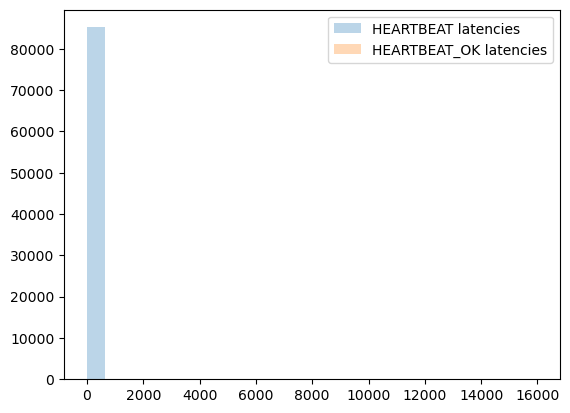

In [13]:
# get heartbeat residuals (effective network delays)
corrections = list()
HEARTBEAT_residuals = list()
HEARTBEAT_OK_residuals = list()
failed_sessions = list()
for (sub, exp, sess, orig_sess), heartbeats_sess in heartbeats.groupby(['subject', 'experiment', 'session', 'original_session']):
    print('------------------------------------------------------------------------------------------------')
    print(sub, exp, 'session', sess, 'original session', orig_sess)
    # print("start heartbeats")
    # print(heartbeats_sess)
    n_task = int((heartbeats_sess.hardware_system == 'task_laptop').sum())
    n_host = int((heartbeats_sess.hardware_system == 'host_pc').sum())

    # Stage 1: fit task-time -> host-time linear correction.
    try:
        res = get_heartbeat_correction(heartbeats_sess, ignore_errors=True, verbose=True, plot=False)
    except Exception as e:
        print(f"  WARNING: could not compute correction (task HBs={n_task}, host HBs={n_host}): "
              f"{type(e).__name__}: {e}. Skipping session.")
        failed_sessions.append((sub, exp, sess, orig_sess, 'fit',
                                f'{type(e).__name__}: {e}', n_task, n_host))
        continue

    res['subject'] = sub
    res['experiment'] = exp
    res['session'] = sess
    res['original_session'] = orig_sess
    corrections.append(pd.DataFrame(res, index=np.arange(len(res))))


    # Stage 2: apply correction to heartbeats and compute cross-validation residuals.
    try:
        heartbeats_task = correct_event_times(heartbeats_sess.query('hardware_system == "task_laptop"'),
                                              res['offset'], res['slope'], time_col='time')
        heartbeats_task = correct_event_times(heartbeats_task,
                                              res['offset'], res['slope'], time_col='time_HEARTBEAT_OK').set_index('count')
        heartbeats_host = heartbeats_sess.query('hardware_system == "host_pc"').set_index('count')

        HEARTBEAT_residuals_sess = list(heartbeats_host.time - heartbeats_task.time)
        HEARTBEAT_OK_residuals_sess = list(heartbeats_host.time_HEARTBEAT_OK - heartbeats_task.time_HEARTBEAT_OK)
        HEARTBEAT_residuals.extend(HEARTBEAT_residuals_sess)
        HEARTBEAT_OK_residuals.extend(HEARTBEAT_OK_residuals_sess)
    except Exception as e:
        print(f"  WARNING: fit succeeded (slope={res['slope']:.9f}, offset={res['offset']:.3f} ms) "
              f"but residuals computation failed: {type(e).__name__}: {e}. "
              f"Skipping residuals for this session.")
        failed_sessions.append((sub, exp, sess, orig_sess, 'residuals',
                                f'{type(e).__name__}: {e}', n_task, n_host))
        continue

# plot all network delays
plt.hist(HEARTBEAT_residuals, bins=25, label='HEARTBEAT latencies', alpha=0.3)
plt.hist(HEARTBEAT_OK_residuals, bins=25, label='HEARTBEAT_OK latencies', alpha=0.3)
plt.legend()

corrections = pd.concat(corrections) if corrections else pd.DataFrame()
if failed_sessions:
    print(f"\nFailed sessions ({len(failed_sessions)}):")
    failed_df = pd.DataFrame(failed_sessions,
                             columns=['subject', 'experiment', 'session', 'original_session',
                                      'stage', 'error', 'n_task_hbs', 'n_host_hbs'])
    print(failed_df.to_string())

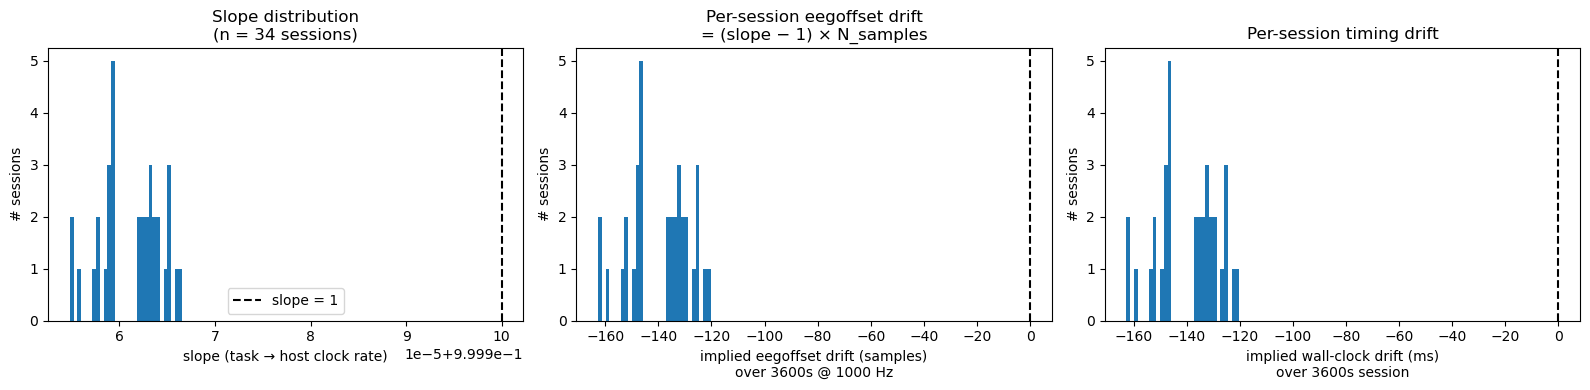

Slope across 34 sessions:
  median = 0.999962231
  mean   = 0.999961291
  std    = 3.25e-06
  |slope - 1| range: [3.34e-05, 4.52e-05]

Implied eegoffset drift over a 3600s session at 1000 Hz:
  median |drift| = 136.0 samples (136.0 ms)
  max    |drift| = 162.7 samples (162.7 ms)

Average heartbeat roundtrip latency across sessions:
  median = 0.952 ms
  mean   = 0.979 ms


In [14]:
# ---------- Evaluate the heartbeat correction across sessions ----------
# slope distribution + implied eegoffset drift over a typical 1-hour session.

if corrections.empty:
    print('No successful corrections to evaluate.')
else:
    sess_keys = ['subject', 'experiment', 'session']
    sess_slopes = corrections.groupby(sess_keys).slope.first()
    sess_offsets = corrections.groupby(sess_keys).offset.first()
    sess_avg_lat = corrections.groupby(sess_keys).average_latency.first()

    # Implied eegoffset drift if a session ran 1 hour at 1000 Hz.
    # eegoffset_corrected = eegoffset * slope, so drift = (slope - 1) * N_samples.
    SFREQ_REF = 1000.0
    SESS_SECONDS = 3600
    n_samples_ref = SESS_SECONDS * SFREQ_REF
    drift_samples_1hr = (sess_slopes - 1) * n_samples_ref
    drift_ms_1hr = drift_samples_1hr / SFREQ_REF * 1000  # = (slope-1) * SESS_SECONDS * 1000

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].hist(sess_slopes, bins=30)
    axes[0].axvline(1.0, color='k', linestyle='--', label='slope = 1')
    axes[0].set_xlabel('slope (task → host clock rate)')
    axes[0].set_ylabel('# sessions')
    axes[0].set_title(f'Slope distribution\n(n = {len(sess_slopes)} sessions)')
    axes[0].legend()

    axes[1].hist(drift_samples_1hr, bins=30)
    axes[1].axvline(0.0, color='k', linestyle='--')
    axes[1].set_xlabel(f'implied eegoffset drift (samples)\nover {SESS_SECONDS}s @ {int(SFREQ_REF)} Hz')
    axes[1].set_ylabel('# sessions')
    axes[1].set_title('Per-session eegoffset drift\n= (slope − 1) × N_samples')

    axes[2].hist(drift_ms_1hr, bins=30)
    axes[2].axvline(0.0, color='k', linestyle='--')
    axes[2].set_xlabel(f'implied wall-clock drift (ms)\nover {SESS_SECONDS}s session')
    axes[2].set_ylabel('# sessions')
    axes[2].set_title('Per-session timing drift')

    plt.tight_layout()
    plt.show()

    # Stats
    print(f"Slope across {len(sess_slopes)} sessions:")
    print(f"  median = {sess_slopes.median():.9f}")
    print(f"  mean   = {sess_slopes.mean():.9f}")
    print(f"  std    = {sess_slopes.std():.2e}")
    print(f"  |slope - 1| range: [{(sess_slopes - 1).abs().min():.2e}, {(sess_slopes - 1).abs().max():.2e}]")
    print()
    print(f"Implied eegoffset drift over a {SESS_SECONDS}s session at {int(SFREQ_REF)} Hz:")
    print(f"  median |drift| = {drift_samples_1hr.abs().median():.1f} samples ({drift_ms_1hr.abs().median():.1f} ms)")
    print(f"  max    |drift| = {drift_samples_1hr.abs().max():.1f} samples ({drift_ms_1hr.abs().max():.1f} ms)")
    print()
    print(f"Average heartbeat roundtrip latency across sessions:")
    print(f"  median = {sess_avg_lat.median():.3f} ms")
    print(f"  mean   = {sess_avg_lat.mean():.3f} ms")

Example: subject_alias=R1204T_1  bids_subject=R1204T  / RepFR1 / ses-0
  slope  = 0.999962312  (|slope - 1| = 3.77e-05)
  offset = 61534488.207 ms


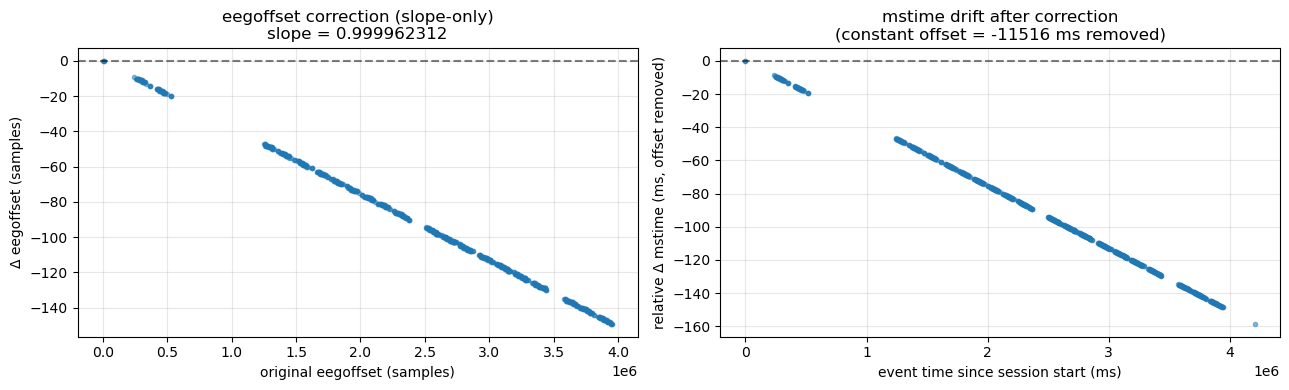


Per-event correction summary for R1204T_1 / RepFR1 / ses-0:
  Δ eegoffset:  min = -149, max = 0, max |Δ| = 149 samples
  Δ mstime constant (heartbeat offset) = -11516.340 ms
  Δ mstime slope-induced drift over session: min = -158.406, max = 0.000, max |Δ| = 158.406 ms


In [15]:
# ---------- Demonstrate correction on one example session ----------
# Loads events for the first session that successfully fit, applies the
# heartbeat correction (full to mstime, slope-only to eegoffset), and plots
# delta_eegoffset and delta_mstime so you can eyeball whether the fix looks
# sensible.

if corrections.empty:
    print('No successful corrections to demonstrate.')
else:
    example = corrections.iloc[0]
    sub_alias = example.subject  # NB: heartbeats df stores subject_alias under `subject`
    exp_e = example.experiment
    sess_e = int(example.session)
    slope_e = float(example.slope)
    offset_e = float(example.offset)

    # `corrections.subject` is the subject_alias (because get_heart stamps
    # the alias into the heartbeats df). Look up the data_index row by
    # subject_alias first, fall back to subject for cases where alias is NaN.
    matches = data.query("subject_alias == @sub_alias and experiment == @exp_e and session == @sess_e")
    if matches.empty:
        matches = data.query("subject == @sub_alias and experiment == @exp_e and session == @sess_e")
    if matches.empty:
        print(f'No data_index row found for {sub_alias} / {exp_e} / ses-{sess_e}.')
    else:
        row = matches.iloc[0]
        sub_bids = row.subject  # cmlreader expects the BIDS subject, not the alias
        print(f"Example: subject_alias={sub_alias}  bids_subject={sub_bids}  / {exp_e} / ses-{sess_e}")
        print(f"  slope  = {slope_e:.9f}  (|slope - 1| = {abs(slope_e - 1):.2e})")
        print(f"  offset = {offset_e:.3f} ms")

        r_ex = CMLReader(subject=sub_bids, experiment=exp_e, session=sess_e,
                         localization=row.localization, montage=row.montage)
        events_orig = r_ex.load('events')

        # Apply correction (mirrors fix_heartbeats_for_session in fix_heartbeats_sys4.py)
        eegoffset_dtype = events_orig['eegoffset'].dtype
        events_corrected = correct_event_times(events_orig, offset_e, slope_e, time_col='mstime')
        events_corrected = correct_event_times(events_corrected, 0, slope_e, time_col='eegoffset')
        events_corrected['eegoffset'] = events_corrected['eegoffset'].round().astype(eegoffset_dtype)

        delta_eegoffset = events_corrected.eegoffset.astype(float) - events_orig.eegoffset.astype(float)
        delta_mstime = events_corrected.mstime.astype(float) - events_orig.mstime.astype(float)
        # remove the constant offset to visualize slope-induced drift only
        rel_delta_mstime = delta_mstime - delta_mstime.iloc[0]

        fig, axes = plt.subplots(1, 2, figsize=(13, 4))

        axes[0].plot(events_orig.eegoffset.values, delta_eegoffset.values, '.', alpha=0.5)
        axes[0].axhline(0, color='k', linestyle='--', alpha=0.5)
        axes[0].set_xlabel('original eegoffset (samples)')
        axes[0].set_ylabel('Δ eegoffset (samples)')
        axes[0].set_title(f'eegoffset correction (slope-only)\nslope = {slope_e:.9f}')
        axes[0].grid(alpha=0.3)

        axes[1].plot(events_orig.mstime.values - events_orig.mstime.iloc[0],
                     rel_delta_mstime.values, '.', alpha=0.5)
        axes[1].axhline(0, color='k', linestyle='--', alpha=0.5)
        axes[1].set_xlabel('event time since session start (ms)')
        axes[1].set_ylabel('relative Δ mstime (ms, offset removed)')
        axes[1].set_title(f'mstime drift after correction\n(constant offset = {delta_mstime.iloc[0]:.0f} ms removed)')
        axes[1].grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

        print()
        print(f"Per-event correction summary for {sub_alias} / {exp_e} / ses-{sess_e}:")
        print(f"  Δ eegoffset:  min = {delta_eegoffset.min():.0f}, max = {delta_eegoffset.max():.0f}, "
              f"max |Δ| = {delta_eegoffset.abs().max():.0f} samples")
        print(f"  Δ mstime constant (heartbeat offset) = {delta_mstime.iloc[0]:.3f} ms")
        print(f"  Δ mstime slope-induced drift over session: "
              f"min = {rel_delta_mstime.min():.3f}, max = {rel_delta_mstime.max():.3f}, "
              f"max |Δ| = {rel_delta_mstime.abs().max():.3f} ms")

In [16]:
len(heartbeats)

182750

In [17]:
len(heartbeats.query('hardware_system == "task_laptop"'))

91419

In [18]:
len(HEARTBEAT_residuals_sess)

2742

In [19]:
len(HEARTBEAT_residuals)

85372

Proportion of HERTBEAT_OK delays > 50 ms: 0.0%


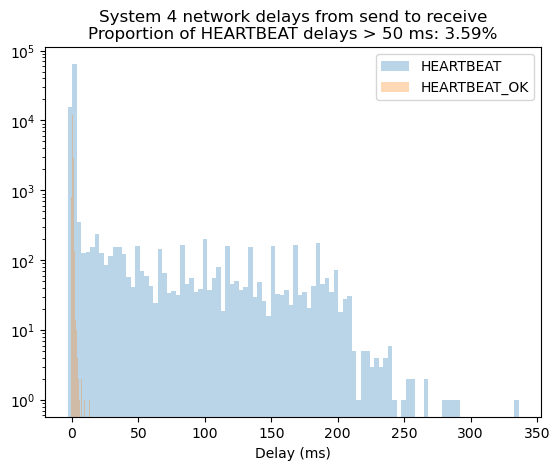

In [20]:
# plot network delays after excluding outliers

# exclude outliers
# mask = np.ones_like(HEARTBEAT_residuals).astype(bool)
mask = np.logical_and(np.abs(HEARTBEAT_residuals) < 1e3, np.abs(HEARTBEAT_OK_residuals) < 1e3)
plt.hist(np.array(HEARTBEAT_residuals)[mask], bins=100, label='HEARTBEAT', alpha=0.3)
plt.hist(-np.array(HEARTBEAT_OK_residuals)[mask], bins=100, label='HEARTBEAT_OK', alpha=0.3)
plt.yscale('log')
plt.legend()
plt.xlabel('Delay (ms)')
long_delay = 50  # ms
prop_long_delay = (np.abs(np.array(HEARTBEAT_residuals)[mask]) > long_delay).mean()
prop_long_delay_host = (np.abs(np.array(HEARTBEAT_OK_residuals)[mask]) > long_delay).mean()
_ = plt.title(f'System 4 network delays from send to receive\nProportion of HEARTBEAT delays > {long_delay} ms: {prop_long_delay * 100:0.4}%')
print(f'Proportion of HERTBEAT_OK delays > {long_delay} ms: {prop_long_delay_host * 100:0.4}%')


Event timing questions:

How are the following event columns derived in event_creation?
- eegoffset:
    - system 4: 
    - system 3: 
    - system 2: 
- mstime:
    - system 4: 
    - system 3: 
    - system 2: 

Can the existing event parsers be used for parsing the session.json/l (with minor adjustments)?

In [21]:
# check absolute HEARTBEAT event times
i = 15
mstime = heartbeats.time.iloc[i + 1]  # Example milliseconds timestamp
converted_datetime = ms_to_datetime(mstime)
print(f'Time of heartbeat {i + 1}:', converted_datetime)

converted_datetime1 = ms_to_datetime(heartbeats.time.iloc[i + 1])
converted_datetime2 = ms_to_datetime(heartbeats.time.iloc[i + 2])
print('Time to next heartbeat (s):', converted_datetime2 - converted_datetime1)


Time of heartbeat 16: 2021-09-30 17:32:07.490460
Time to next heartbeat (s): 0:00:01.000050


In [22]:
# confirm that HEARTBEATs are all separated by ~1 second
def check_heartbeat_onsets(heartbeats, min_heartbeat_diff=990, max_heartbeat_diff=1010):
    if len(heartbeats) == 0: return
    sess_cols = ['subject', 'experiment', 'session']
    heartbeats.loc[:, ['time_diff']] = heartbeats[sess_cols + ['time']].groupby(sess_cols).diff().reset_index(drop=True).to_numpy()
    heart_off = np.logical_or(heartbeats.time_diff.dropna() > max_heartbeat_diff, 
                              heartbeats.time_diff.dropna() < min_heartbeat_diff)
    if heart_off.mean():
        print(f'WARNING: some HEARTBEAT events not separated by approximately 1 second '
              f'(acceptable range: [{min_heartbeat_diff}, {max_heartbeat_diff}] ms). '
              f'Proportion of heartbeats outside range: {heart_off.mean()}')

check_heartbeat_onsets(heartbeats.query('hardware_system == "task_laptop"'))

Text(0.5, 0, 'Latency (ms)')

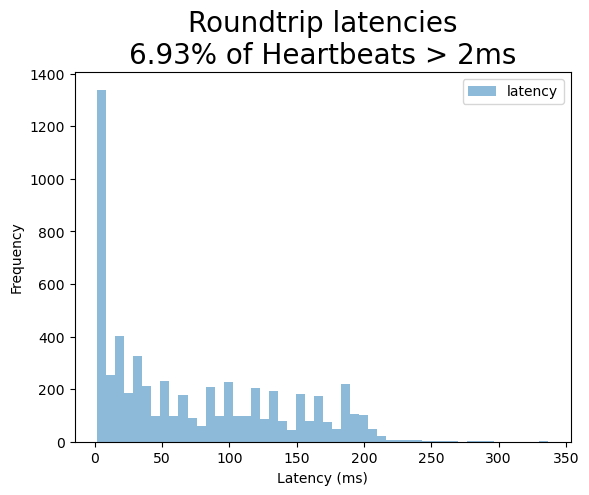

In [23]:
# plot heartbeat roundtrip latencies
bpm_err = heartbeats.query('hardware_system == "task_laptop"').copy().latency
# threshold for marking heartbeat trips as "high latency"
threshold = 2  # ms
norm = bpm_err[bpm_err < threshold].count()
bpm_err = bpm_err[bpm_err > threshold]
bpm_err = bpm_err[bpm_err < 1000]  # exclude extreme outliers (some latencies > 1e6)
no_norm = bpm_err[bpm_err > threshold].count()
percent = no_norm/(norm+no_norm) * 100
percent = round(percent, 2)

_max = int(round(bpm_err.max()))

# *** Sets up the axes for all of the plots
# set_axes(figsize = (7, 5), fontsize = 18)
bins = 50 #np.arange(0, _max+2, step = 1)
# *** Plots the latencies *** #
bpm_err.plot.hist(bins = bins, alpha = 0.5)
plt.legend()
plt.title(f'Roundtrip latencies\n{str(percent)}% of Heartbeats > {threshold}ms', fontsize=20)
plt.xlabel('Latency (ms)')
